In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [21]:
load_dotenv()

True

In [22]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7
)

In [23]:
# Tools
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)

@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2 + 2, math.sqrt(16), 10 * 5
    """

    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=IGWD6PDN8J26RPOW"
    r = requests.get(url)
    return r.json()



@tool
def get_current_weather(location: str) -> str:
    """
    Get the current real-time weather for a given city or location.

    Args:
        location: City or location name, for example:
                  "Dhaka", "London, UK", or "New York, US".

    Returns:
        A formatted current weather report.
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")

    if not api_key:
        return (
            "Weather API key is missing. "
            "Set the OPENWEATHER_API_KEY environment variable."
        )

    try:
        # Step 1: Convert the location name into latitude and longitude
        geocoding_url = "https://api.openweathermap.org/geo/1.0/direct"

        geocoding_params = {
            "q": location,
            "limit": 1,
            "appid": api_key,
        }

        geo_response = requests.get(
            geocoding_url,
            params=geocoding_params,
            timeout=10,
        )
        geo_response.raise_for_status()

        locations: list[dict[str, Any]] = geo_response.json()

        if not locations:
            return f"Could not find the location: {location}"

        latitude = locations[0]["lat"]
        longitude = locations[0]["lon"]
        resolved_name = locations[0].get("name", location)
        country = locations[0].get("country", "")
        state = locations[0].get("state", "")

        # Step 2: Get current weather using latitude and longitude
        weather_url = "https://api.openweathermap.org/data/2.5/weather"

        weather_params = {
            "lat": latitude,
            "lon": longitude,
            "appid": api_key,
            "units": "metric",
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10,
        )
        weather_response.raise_for_status()

        weather_data = weather_response.json()

        temperature = weather_data["main"]["temp"]
        feels_like = weather_data["main"]["feels_like"]
        humidity = weather_data["main"]["humidity"]
        pressure = weather_data["main"]["pressure"]
        description = weather_data["weather"][0]["description"]
        wind_speed = weather_data.get("wind", {}).get("speed", "N/A")
        visibility_meters = weather_data.get("visibility")

        visibility_km = (
            round(visibility_meters / 1000, 1)
            if visibility_meters is not None
            else "N/A"
        )

        location_parts = [resolved_name]

        if state:
            location_parts.append(state)

        if country:
            location_parts.append(country)

        display_location = ", ".join(location_parts)

        return (
            f"Current weather in {display_location}:\n"
            f"- Condition: {description.title()}\n"
            f"- Temperature: {temperature}°C\n"
            f"- Feels like: {feels_like}°C\n"
            f"- Humidity: {humidity}%\n"
            f"- Pressure: {pressure} hPa\n"
            f"- Wind speed: {wind_speed} m/s\n"
            f"- Visibility: {visibility_km} km"
        )

    except requests.Timeout:
        return "The weather service request timed out. Please try again."

    except requests.HTTPError as error:
        status_code = error.response.status_code if error.response else "unknown"

        if status_code == 401:
            return "The OpenWeather API key is invalid or inactive."

        return f"Weather API returned an HTTP error: {status_code}"

    except requests.RequestException as error:
        return f"Could not connect to the weather service: {error}"

    except (KeyError, TypeError, ValueError) as error:
        return f"Unexpected weather API response: {error}"


In [24]:
# Make tool list
tools = [search_tool,calculator, get_stock_price,get_current_weather]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [25]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [26]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [27]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    

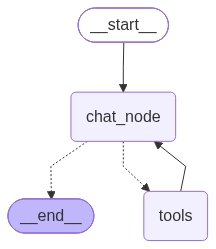

In [28]:
chatbot = graph.compile()

chatbot

In [29]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 8989898*90909090+5404040?")]})
print(out["messages"][-1].content)

[{'type': 'text', 'text': 'The result of $8,989,898 \\times 90,909,090 + 5,404,040$ is **817,263,451,776,860** (or $817.26\\text{ trillion}$).', 'extras': {'signature': 'EtUECtIEAWkUfRP8LCY8sPURfg21USdfIPGezxtksKnQCW+CMCvgzTEg1yNOb1C6l5OPKRXMtbzRqJJl93gSzfySfLZTo9iH5IEz47kJrLTu2G4RpVzW6hIm+ppqmSrzs3ibIwTizmiiT6KOQh/hct7Hzw0xf1k4KSWYQg5so5Fktt6Fkt6ma5SXPLTY7kWSyrosVeb6PFHbIVK+KA+v9+9pf+iJaSeFQdgmqb4j93eYJsnxb9X7gn1jITzZDq/m3NlKbtees7GTrPwr/UuL8v13dIl+uF1YPBUJlJ7ey4So0+VpJjF5czRsj0HJ/KHqNvzgGmitxsXyKtZTMmDUMSKkJEOAtDdwZjUIc5bke/mvKryklbshyshkFpDHEqNPEIhrATWbaTglQVov/RhLPzmORagnk1WhYSAoxaSG43U6tYEYSkRH4bQRMbTlRtyTxXGiqfCLJjuJlXW3K+jUMcki0OBMcWOSwx1QW5MbUrIDiw6OolR5tDyR5P4HUzspyATyiQHLFKd7jz9QkKRchbihjrZwGqe3JVf9mULuJxZXLTUu9rDJyoW8f0w8kNVqqrsehSclP4xsbuV4kpvKVTxGeIlBcN6TdPyqC/l43ceQPUPEYJfilrs2HNELidbPzdPFjUbYCqXAuPb3N4drQDBGm7MmCGWHgRZ03vguCRQxP7bGZADXhAk/F2PoOZYDzHeN+CQfSyWTeSaf9Y9CJ6a5pDafjD0nK9gjp5NENuGDHYUXjHBH9zEMFILrFgj62tbksCr0F06R7GQ3+7xo3O0TDizKIUbt'}}]


In [ ]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="what is the new movie releases in 2026")]})
print(out["messages"][-1].content[0])

In [31]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

[{'type': 'text', 'text': 'The current stock price of Apple (AAPL) is **$337.02** per share.\n\nUsing the calculator to compute the cost of 50 shares:\n$$337.02 \\times 50 = \\mathbf{\\$16,851.00}$$\n\nIt will cost **$16,851.00** to purchase 50 shares of Apple.', 'extras': {'signature': 'EuUDCuIDAWkUfRODCHFi60jbHZ95as2IuMWGWNwbOP2s5BGWp/mCG5vAvryQNrFKmke96z879N5GKMGgUfytr+ETL7rUz43kDcdLabOoHcxTO37o4pU7JHkIz+a4PESK1YFLksakAQgsdNMbydatjZrrc9oJqaPrPFEj9UZfRZOYcKnR3nVtgYnooZnJQMrU3EJllY+F2QAvY/4Y/7zgKQL3tg2Qw8Q8GBCLUo7ghELm5ktrjrFDCq+l+x8FchEIOJ2S8zofVhzuPWiEzIN5I05zHYaoKm+rnY7OBMVDZ0kZKj1jgRz8j1JFDI6OOo3MHjA02GpgapSsoMPARBtcyP2NX6glIfqllNXTf726xCuPxiOiC8bjKSk/OON9XQbKRec3AUKn/JePcSCSeZlnNfcUbrdpc6qOsotqaFSYA5erE44MgIsr/R2Q8r3WHGGqR2bj2RmToEMKmnkQXaRVge+MhhLi7DSWZ7X7UKlTgzS+sf6ETgv4rpyLptAfowwXuZ8dn1bUV5dOJcFgCuHg9C/XuquRObv4pv8I8uSufWmA1FJKBo4JoLITA3AbT5u0LRlaaMG8Kjq0N8RQeNjItEEUu4Fr20GqF4I40CPV8eguJ3IiwautV7OOPi0pJqL+6bBD9yKAcgU='}}]


In [32]:
print(out["messages"][-1].content[0]['text'])

The current stock price of Apple (AAPL) is **$337.02** per share.

Using the calculator to compute the cost of 50 shares:
$$337.02 \times 50 = \mathbf{\$16,851.00}$$

It will cost **$16,851.00** to purchase 50 shares of Apple.


In [33]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the current weather in Sricity Andrapradesh?")]})
print(out["messages"][-1].content)

[{'type': 'text', 'text': 'The current weather in **Sri City, Andhra Pradesh** is as follows:\n\n* **Condition:** Overcast Clouds\n* **Temperature:** 29.6°C (85.3°F)\n* **Feels Like:** 32.7°C (90.9°F)\n* **Humidity:** 63%\n* **Wind Speed:** 3.1 m/s (approx. 11.2 km/h)\n* **Visibility:** 10 km\n* **Atmospheric Pressure:** 1004 hPa', 'extras': {'signature': 'EpQDCpEDAWkUfROtEqH/klPGiEOpGY9p+OaEa8TTG3tLiGX9TnmQXal68Qlsye3MZBlEQiQnZfstRgilbBBP/t2a99S1b1IKAnR1EH1zP14/rqCSDw4gCEDenaqjebIUGRgZa41F0gtEDbfBrmn5EH1RuPyXVKESRNnqKRj4mlN3UDLXqqjl/9+Ozxc5NhgrUm+ETJjaUXnLgd923kjiBCGlD7OiCci8BFa3zkh6r3p4aD9/1YsC3XLtfBZY+zYmOG1xLusW6Q/VbyEoYJ+Zkt+OsMAQQA79pRaik/RDgAMDMTS+exHlG/4zxFaHdTVd60FttxLmf1DlcPh5R7quG5vltG0uUjw/ubXWt7J2/uvDRPkCwNdqhbOoNDS7GzyFp+arqABqOBd9s4R5Inw+fl+S5o7vq9WP3C3XalvLCv+AaZ87rh/4kptztNkGkyjJbNAWXu1/6ECRMDSOJt2MrwH2vyZOCGxbtMtBkPPink0QysZjuoG+L6pFyWUxolIQmUADNThHNn1CEf89EP7WXON4IOAHf+k='}}]
